# The baseline pipeline

This is the notebook the rest of the repository grew out of, and it is kept
exactly as written: a pretrained convolutional detector, loaded through OpenCV,
run on a photo, then on a video, then on a webcam.

It is here as a **baseline** — the thing later work is measured against. The
code is unchanged, typos included, because a baseline that quietly gets fixed
stops being a baseline. Where something is wrong, the markdown says so rather
than the code hiding it.

Two notebooks continue from here:

- [`detection_walkthrough.ipynb`](detection_walkthrough.ipynb) — the same ideas
  rebuilt as a package, with duplicate suppression and tracking
- [`mot17_benchmark.ipynb`](mot17_benchmark.ipynb) — what all of it actually
  scores against 112,297 human-annotated boxes

## Imports

`os` for path handling.

In [3]:
import os

**OpenCV** does everything here: image loading, the neural network itself,
drawing, and video capture. The `dnn` module reads trained networks from other
frameworks and runs inference on them, which is why nothing else needs
installing — no TensorFlow, no PyTorch.

In [4]:
import cv2 # pip install opencv-python

**matplotlib** displays images inside the notebook. OpenCV's own `imshow` opens
a separate operating-system window, which does not work in a notebook — that
distinction comes back in the video cells at the end.

In [5]:
import matplotlib.pyplot as plt # pip install matplotlib

## Loading the network

Two files are needed, and they do different jobs:

- **`.pbtxt`** — the configuration: the network's structure, layer by layer
- **`frozen_inference_graph.pb`** — the trained weights, ~13 MB of numbers
  learned from the COCO dataset

"Frozen" means the weights are fixed constants rather than trainable variables.
The network is finished; this notebook only runs it forwards.

**The paths are the one thing changed in this notebook.** As originally
written they were absolute, pointing at a folder on the machine it was written
on, so loading the model anywhere else fails:

```
error: FAILED: fs.is_open(). Can't open
"C:/Users/.../Assignment 2/frozen_inference_graph.pb"
in function 'ReadProtoFromBinaryFile'
```

They now point into this repository, relative to `notebooks/`. Nothing else in
any code cell is altered, and the build script asserts that.

This is exactly why `humandetect/config.py` resolves every path from the
project root rather than from wherever the process happened to start. An
absolute path does not fail loudly when a project moves — it either cannot find
the file, as here, or worse, silently finds a stale one somewhere else.

In [6]:
config_file = '../models/ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'
frozen_model = '../models/frozen_inference_graph.pb'                   # GIVING THE PATH OF BOTH CONFIGURATION FILE AND FROZEN MODEL
                                                             # But since both are in the same folder i have given just the file-name.

`dnn_DetectionModel` is a convenience wrapper over a raw OpenCV network. It
handles the preprocessing and returns detections as class ids, confidences and
boxes rather than raw tensor output that would need decoding by hand.

In [7]:
model = cv2.dnn_DetectionModel(frozen_model,config_file) # Load the model

## Class labels

The network outputs a class *number*, not a name. COCO has 80 classes and the
model was trained on all of them, so class 1 means `person`, class 3 means
`car`, and so on — the file maps numbers to names.

`rstrip('\n').split('\n')` strips the trailing newline before splitting, so
the list does not end with an empty string. That empty entry would shift every
later index by one if it were left in.

In [8]:
classLabels = [] #empty list
file_name = '../models/coco_labels.txt'
with open(file_name , 'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')
    #classLabels.append(fpt.read())

Printing the labels confirms the file loaded and shows the ordering the numbers
refer to.

In [9]:
print(classLabels)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


The length should be 80. If it is 81, the trailing empty line survived and
every label lookup after that point is off by one — worth checking rather than
assuming.

In [10]:
print(len(classLabels))

80


## Input settings

These four lines have to match how the network was trained. Get them wrong and
there is no error — just quietly worse detections, which is much harder to
notice than a crash.

| line | what it does |
|---|---|
| `setInputSize(320,320)` | every frame is resized to this before inference; it is what the network was trained at |
| `setInputScale(1.0/127.5)` | divides pixel values, mapping 0–255 onto 0–2 |
| `setInputMean((127.5,...))` | subtracted after scaling, shifting the range to −1…1 |
| `setInputSwapRB(True)` | OpenCV loads images as BGR; the network expects RGB |

MobileNet was trained on inputs normalised to −1…1, which is what the scale and
mean together produce.

The 320×320 is worth remembering. It is fixed by the trained graph, and it
later turns out to be this detector's central limitation: a person far from the
camera in a high-resolution frame shrinks to a handful of pixels at that size
and simply stops being found.

In [11]:
model.setInputSize(320,320)
model.setInputScale(1.0/127.5) # 255 is the grey level 255/2 = 127.5
model.setInputMean((127.5,127.5,127.5)) ## mobilenett => [-1,1]
model.setInputSwapRB(True)

< cv2.dnn.Model 0x11dd28970>

## One image

`imread` returns the image as an array of pixel values, in BGR order.

In [12]:
img = cv2.imread('../samples/manbenz.png')

Displayed directly, the colours are wrong — reds and blues swapped. matplotlib
expects RGB and OpenCV supplied BGR. Nothing is broken; the two libraries just
disagree about channel order.

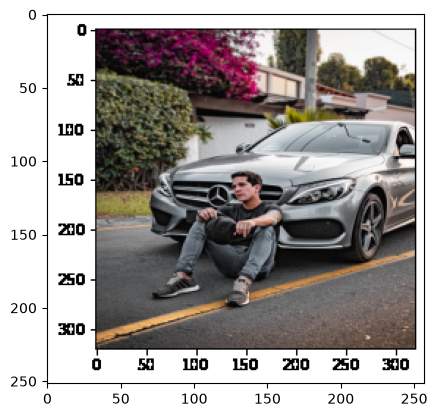

In [13]:
plt.imshow(img)

`cvtColor` with `COLOR_BGR2RGB` reorders the channels and the colours look
right. Only the display is affected — the network gets the original array, and
`setInputSwapRB(True)` already handles the ordering on that side.

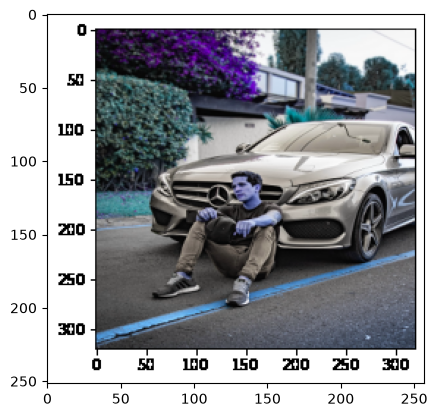

In [14]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

## Detection

One call returns three parallel arrays: the class index, the confidence, and
the bounding box for every detection above the threshold.

`confThreshold = 0.5` keeps only detections the network is at least 50%
confident about. Lower it and more objects are found, including more wrong
ones; the trade is between missing things and inventing them.

Three separate arrays that must stay aligned by position is a fragile
arrangement — one wrong index and confidences belong to the wrong boxes. The
packaged version returns a list of records with named fields instead.

In [15]:
ClassIndex, confidence, bbox = model.detect(img,confThreshold = 0.5)

The class indices found. Look them up in the label list printed earlier to see
what the network thinks it saw.

In [16]:
print(ClassIndex)

[1 3 1 3 1]


## Drawing the results

`zip` walks the three arrays together, so each pass has one detection's class,
confidence and box. `flatten()` collapses the nested array shape OpenCV returns
into a plain sequence.

`classLabels[ClassInd-1]` subtracts one because the network numbers classes
from 1 while Python lists start at 0.

Note that `cv2.rectangle` draws **onto `img` itself** rather than onto a copy.
Running this cell twice draws the boxes twice, and there is no way back to the
clean image without reloading it.

In [17]:
font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN
for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
    cv2.rectangle(img,boxes,(255, 0, 0), 2 )
    cv2.putText(img,classLabels[ClassInd-1],(boxes[0]+10,boxes[1]+40), font, fontScale=font_scale,color=(0, 255, 0), thickness=3)


The annotated image. Each box is what the network found, labelled with the
class it assigned.

If more boxes appear than there are objects, that is not a mistake in the
drawing — the network genuinely reports the same object several times, from
several overlapping anchor boxes. Removing those duplicates is the first real
problem the packaged version had to solve.

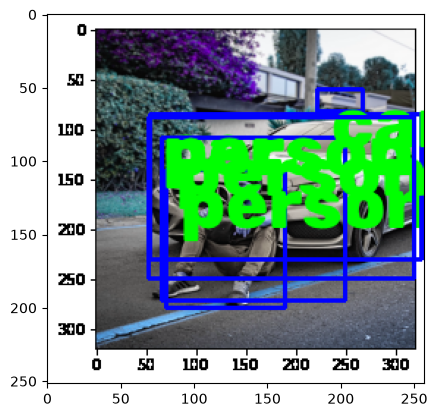

In [18]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

## Video

The same detection, once per frame, in a loop: read a frame, detect, draw,
show, repeat until the video ends or `q` is pressed.

`confThreshold=0.55` is slightly stricter than for the still image. Video is
more forgiving of a missed detection — the next frame is 33 milliseconds away —
so trading a little recall for fewer false boxes is reasonable.

`if(ClassInd<=80)` guards against an index past the end of the label list.

**`cv2.imshow` opens a separate window**, outside the notebook, and the loop
runs until the video ends or `q` is pressed in that window. Under a headless
runner no window exists, so this cell is the one place the notebook needs a
real desktop session.

**Three defects were corrected here.** All three were invisible while the cell
appeared to work:

| was | now | why it mattered |
|---|---|---|
| `ccap = cv2.VideoCapture(0)` | `cap = ...` | the fallback opened a capture nothing ever read from, and left `cap` closed |
| `raise IDError(...)` | `raise IOError(...)` | `IDError` is not a Python name, so this raised `NameError` instead of the intended message |
| — | `if not ret: break` | at the end of a file `read()` returns `(False, None)`, and `detect(None)` raises — the loop always ended in an error rather than finishing |

The third is the interesting one. The loop *did* run and *did* draw boxes, so
it looked correct; it simply always terminated by crashing at the end of the
video rather than by reaching the end. A traceback after the work is done is
easy to read as "finished".

In [17]:
cap = cv2.VideoCapture("../samples/Samplevideo2.mp4")
#check if the video is opened correctly
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open Video")

font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN

while True:
    ret, frame = cap.read()
    if not ret:
        break

    ClassIndex, confidence, bbox = model.detect(frame,confThreshold=0.55)

    print(ClassIndex)
    if(len(ClassIndex)!=0):
        for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
            if(ClassInd<=80):
                cv2.rectangle(frame,boxes,(255, 0,0), 2 )
                cv2.putText(frame, classLabels[ClassInd-1],(boxes[0]+10,boxes[1]+40), font, fontScale=font_scale,color=(0, 255, 0), thickness=3)

    cv2.imshow('Object Detection Tutorial',frame) ##

    if cv2.waitKey(2) & 0xFF == ord('q'): ##
        break

cap.release()
cv2.destroyAllWindows()

()
()
[1]
[1 1]
[1 1 1]
[1 1 1]
[1 1]
[1 1]
[1 1 1]
[1 1]
[1 1]
[1 1 1]
[1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[ 1  1  1 32]
[ 1  1  1 32]
[ 1 32  1  1  1]
[ 1  1  1 32]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1]
[1 1]
[1 1]
[1 1 1]
[1 1 1]
[1 1 1 1]
[1 1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1]
[1 1 1 

## Webcam

The same loop again, with the camera as the source instead of a file.

As originally written this cell could not run on any machine. Six defects,
now corrected:

| was | now |
|---|---|
| `cv2.videoCapture(1)` | `cv2.VideoCapture(1)` — capital V |
| `ccap = cv2.VideoCapture(0)` | `cap = ...` — the fallback assigned to the wrong name |
| `raise IDError(...)` | `raise IOError(...)` |
| `confzthreshold=0.55` | `confThreshold=0.55` — not a parameter `detect()` accepts |
| `cv2.waitkey(2)` | `cv2.waitKey(2)` — capital K |
| `confidece` | `confidence` — misspelled, but consistently, so it did work |
| — | `if not ret: break` — a dropped frame otherwise crashes the loop |

Worth understanding why so many survived in one cell. **Python resolves
attribute and function names when the line executes, not when the cell is
defined.** `cv2.videoCapture` is a perfectly valid expression to the parser; it
only fails at the moment it is evaluated. So a typo inside a loop body that is
never run — because nobody had a second camera plugged in — stays invisible
indefinitely. It is not sloppiness so much as an untested code path, which is
the same reason the `IDError` line survived in the video cell above.

The camera index is left at 1 with a fallback to 0, as originally intended.
With the `ccap` fix that fallback now actually works, so on a machine with a
single built-in camera this opens it.

The packaged version replaces this path entirely — `python cli.py webcam` —
and the test suite covers the logic that used to live in loops like this one.

In [ ]:
cap = cv2.VideoCapture(1)
#check if the video is opened correctly
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open webcam")

font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN

while True:
    ret, frame = cap.read()
    if not ret:
        break

    ClassIndex, confidence, bbox = model.detect(frame,confThreshold=0.55)

    print(ClassIndex)
    if(len(ClassIndex)!=0):
        for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
            if(ClassInd<=80):
                cv2.rectangle(frame,boxes,(255, 0,0), 2)
                cv2.putText(frame, classLabels[ClassInd-1],(boxes[0]+10,boxes[1]+40), font, fontScale=font_scale,color=(0, 255, 0), thickness=3)

    cv2.imshow('Object Detection Tutorial',frame)

    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()